Q5 Titanic Survival Prediction 

Perform exploratory data analysis, clean missing values, engineer simple features, train both Logistic Regression and Random Forest models, compare their performance, and explain which model you would deploy. 

Expected Deliverables: EDA, training code, evaluation metrics and justification.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [3]:
df = pd.read_csv("Titanic-Dataset-selected-columns.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500


In [4]:
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nSummary Statistics")
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
dtypes: float64(2), int64(5), str(3)
memory usage: 69.7 KB
None

Missing Values
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

Summary Statistics
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.00000

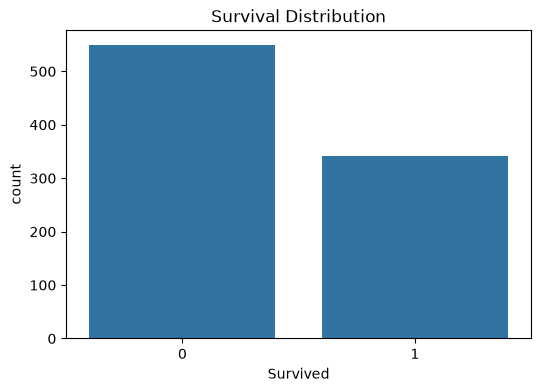

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)

plt.title("Survival Distribution")
plt.show()

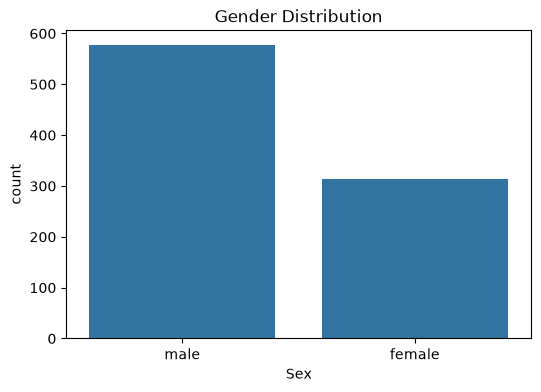

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', data=df)

plt.title("Gender Distribution")
plt.show()

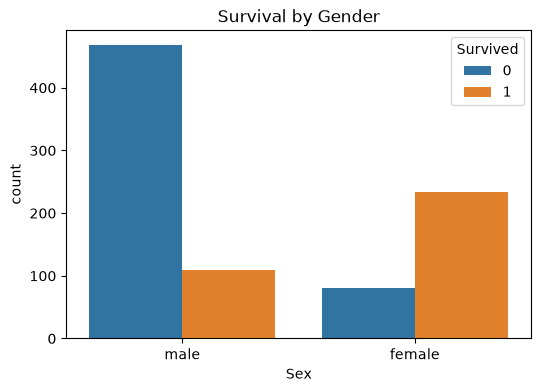

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df)

plt.title("Survival by Gender")
plt.show()

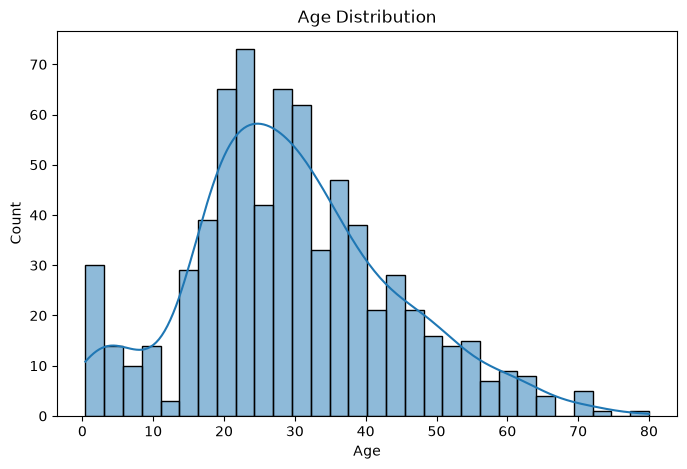

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)

plt.title("Age Distribution")
plt.show()

In [9]:
df['Age'] = df['Age'].fillna(df['Age'].median())

Feature Engineering

In [10]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

In [11]:
encoder = LabelEncoder()

df['Sex'] = encoder.fit_transform(df['Sex'])

In [12]:
X = df[['Pclass',
        'Sex',
        'Age',
        'SibSp',
        'Parch',
        'Fare',
        'FamilySize',
        'IsAlone']]

y = df['Survived']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Logistic Regression

In [14]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [15]:
print("Logistic Regression Accuracy")

print(accuracy_score(y_test, lr_pred))

print("\nConfusion Matrix")

print(confusion_matrix(y_test, lr_pred))

print("\nClassification Report")

print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy
0.7988826815642458

Confusion Matrix
[[90 15]
 [21 53]]

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.86      0.83       105
           1       0.78      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



Random Forest

In [16]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy")

print(accuracy_score(y_test, rf_pred))

print("\nConfusion Matrix")

print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report")

print(classification_report(y_test, rf_pred))

Random Forest Accuracy
0.7988826815642458

Confusion Matrix
[[88 17]
 [19 55]]

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       105
           1       0.76      0.74      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



Comparision

                 Model  Accuracy
0  Logistic Regression  0.798883
1        Random Forest  0.798883


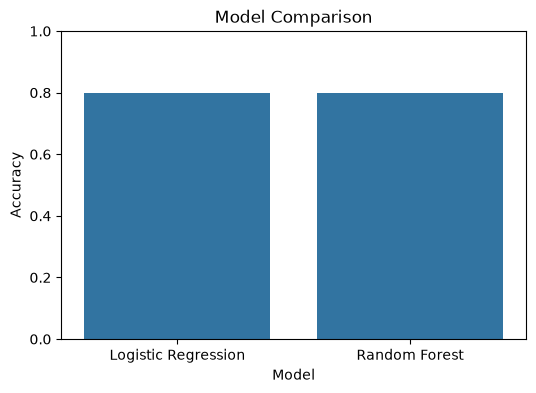

In [17]:
results = pd.DataFrame({

    'Model':[
        'Logistic Regression',
        'Random Forest'
    ],

    'Accuracy':[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ]

})

print(results)

plt.figure(figsize=(6,4))

sns.barplot(
    data=results,
    x='Model',
    y='Accuracy'
)

plt.title("Model Comparison")

plt.ylim(0,1)

plt.show()

Feature Importances - Random Forest

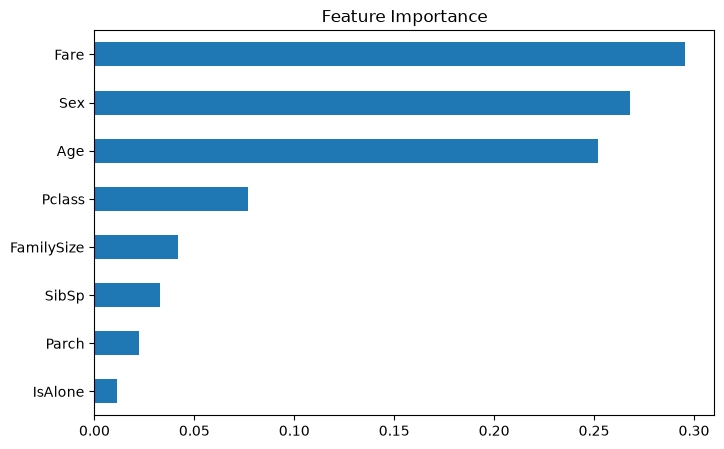

In [18]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Feature Importance")
plt.show()

Visualise one Decison Tree from Random Forest

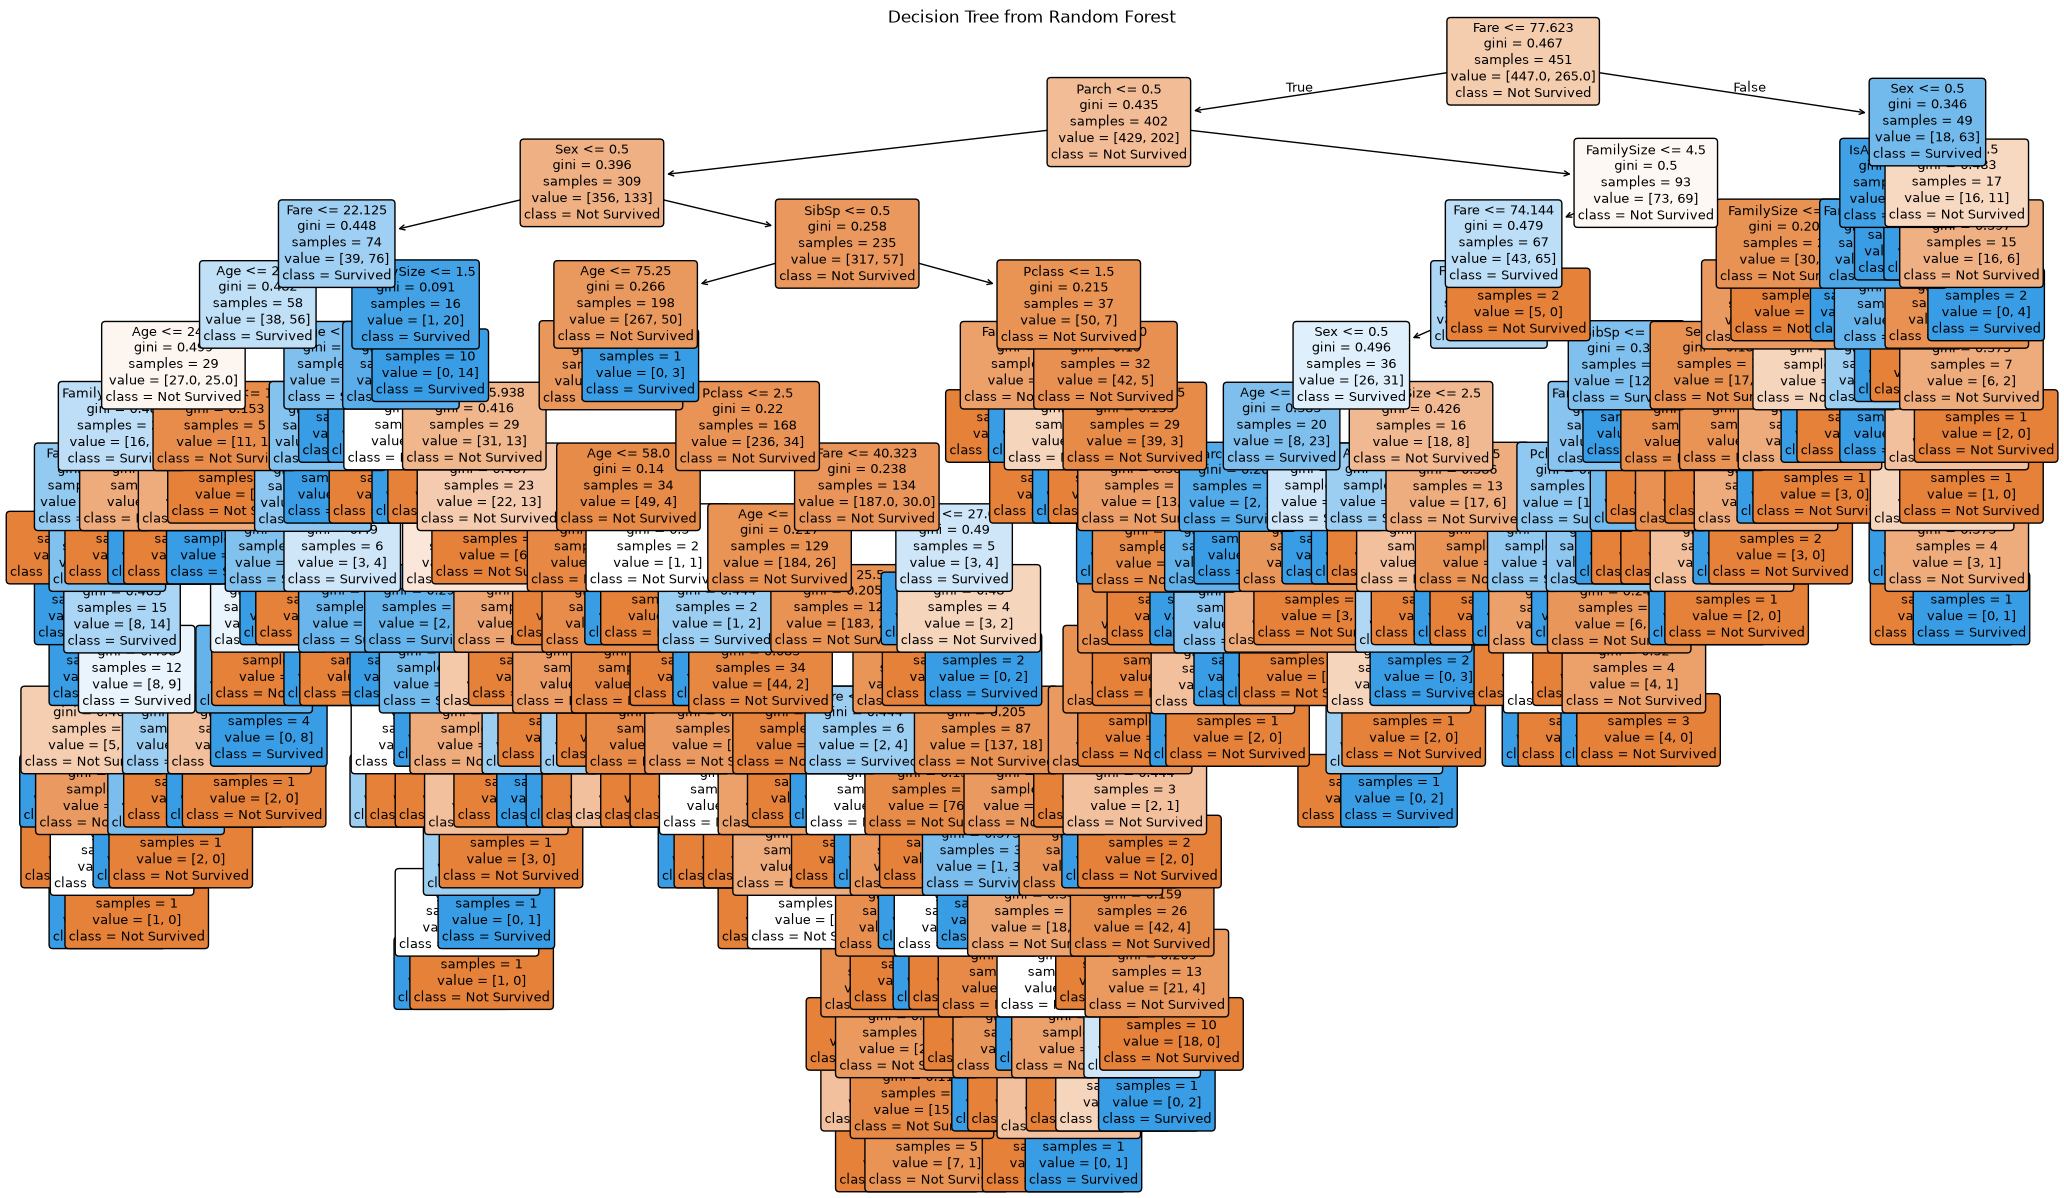

In [19]:
# Select the first tree
tree = rf.estimators_[0]

plt.figure(figsize=(25,15))

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree from Random Forest")
plt.show()

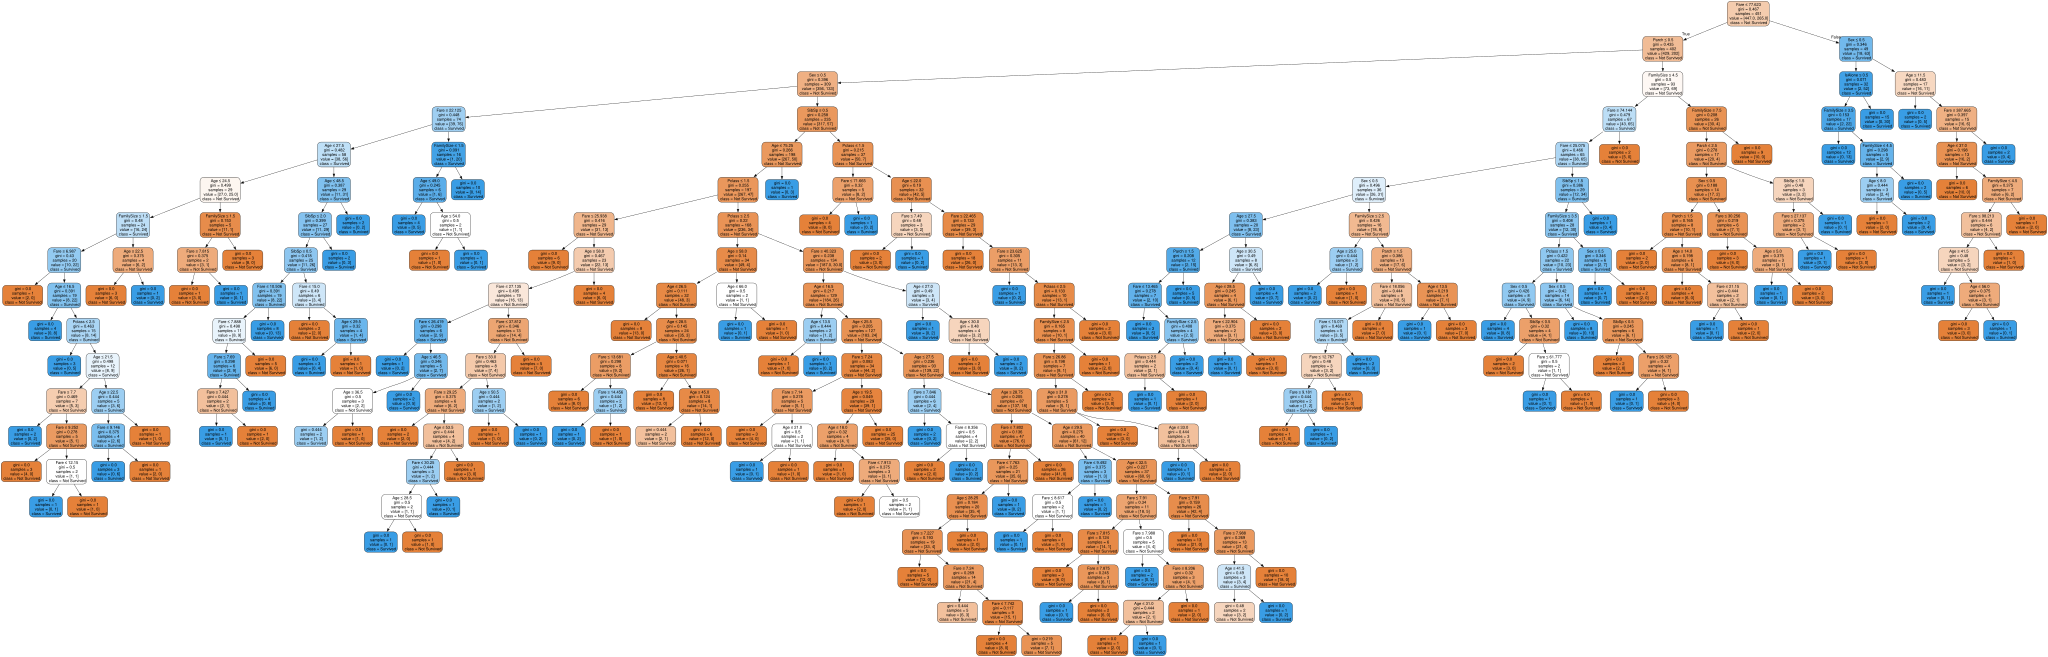

In [21]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    rf.estimators_[0],
    out_file=None,
    feature_names=X.columns,
    class_names=["Not Survived","Survived"],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph